In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [69]:
from pathlib import Path
import os
import pandas as pd

DRIVE_ROOT = Path("/content/drive/MyDrive")

DATA_DIR_NEWS = DRIVE_ROOT / "semantic-drift" / "news_dataset"
DATA_DIR_REDDIT = DRIVE_ROOT / "semantic-drift" / "reddit_data"/ "processed" / "monthly"
RESULTS_DIR = DRIVE_ROOT / "semantic-drift/results"

DATA_DIR_NEWS.mkdir(parents=True, exist_ok=True)
DATA_DIR_REDDIT.mkdir(parents=True, exist_ok=True)

In [70]:
import re

def filter_new_mouse_contexts(contexts):

    positive = [
        r"\bmouse\b",
        r"\bcomputer mouse\b",
        r"\bmouse click\b",
        r"\bscroll\b",
        r"\bcursor\b",
        r"\btrackpad\b"
    ]

    negative = [
        r"\bmouse trap\b",
        r"\bmouse hole\b",
        r"\bmouse ran\b",
        r"\brodent\b"
    ]

    filtered_contexts = []
    for context in contexts:
        is_positive_match = any(re.search(p, context, re.IGNORECASE) for p in positive)
        is_negative_match = any(re.search(n, context, re.IGNORECASE) for n in negative)

        if is_positive_match and not is_negative_match:
            filtered_contexts.append(context)
    return filtered_contexts

In [71]:
def clean_news_contexts_for_word(word, contexts):
    word = word.lower()

    if word == "mouse":
        return filter_new_mouse_contexts(contexts)
    if word == "stream":
        return filter_new_stream_contexts(contexts)
    if word == "tablet":
        return filter_new_tablet_contexts(contexts)

    return contexts

def clean_reddit_contexts_for_word(word, contexts):
    word = word.lower()

    if word == "mouse":
        return filter_new_mouse_contexts(contexts)
    if word == "stream":
        return filter_new_stream_contexts(contexts)
    if word == "tablet":
        return filter_new_tablet_contexts(contexts)

    return contexts

In [72]:
import re

def filter_new_stream_contexts(contexts):

    positive = [
    r"\bstream\b",
    r"\blivestream\b",
    r"\bstreaming\b",
    r"\btwitch\b",
    r"\bnetflix\b",
    r"\bvideo stream\b"
]

    negative = [
    r"\bwater stream\b",
    r"\bmountain stream\b",
    r"\bflowing stream\b"
]

    filtered_contexts = []
    for context in contexts:
        is_positive_match = any(re.search(p, context, re.IGNORECASE) for p in positive)
        is_negative_match = any(re.search(n, context, re.IGNORECASE) for n in negative)

        if is_positive_match and not is_negative_match:
            filtered_contexts.append(context)
    return filtered_contexts

In [73]:
def clean_news_contexts_for_word(word, contexts):
    word = word.lower()

    if word == "stream":
        return filter_new_stream_contexts(contexts)

    return contexts


def clean_reddit_contexts_for_word(word, contexts):
    word = word.lower()

    if word == "stream":
        return filter_new_stream_contexts(contexts)

    return contexts

In [74]:
import re

def filter_new_tablet_contexts(contexts):

    positive = [
    r"\btablet\b",
    r"\bipad\b",
    r"\bandroid tablet\b",
    r"\btablet device\b"
]

    negative = [
    r"\bmedicine tablet\b",
    r"\bpill\b",
    r"\bstone tablet\b"
]

    filtered_contexts = []
    for context in contexts:
        is_positive_match = any(re.search(p, context, re.IGNORECASE) for p in positive)
        is_negative_match = any(re.search(n, context, re.IGNORECASE) for n in negative)

        if is_positive_match and not is_negative_match:
            filtered_contexts.append(context)
    return filtered_contexts

In [75]:
def clean_news_contexts_for_word(word, contexts):
    word = word.lower()

    if word == "tablet":
        return filter_new_tablet_contexts(contexts)

    return contexts


def clean_reddit_contexts_for_word(word, contexts):
    word = word.lower()

    if word == "tablet":
        return filter_new_tablet_contexts(contexts)

    return contexts

In [76]:
def clean_reddit_contexts_for_word(word, contexts):

    word = word.lower()

    if word == "mouse":
        return filter_new_mouse_contexts(contexts)

    if word == "stream":
        return filter_new_stream_contexts(contexts)

    if word == "tablet":
        return filter_new_tablet_contexts(contexts)

    return contexts

In [77]:
def save_contexts_csv(word, source, contexts, save_dir):
    if not contexts:
        # If contexts list is empty, create an empty DataFrame with the expected columns
        df = pd.DataFrame(columns=["word", "source", "text"])
    else:
        df = pd.DataFrame({
            "word": [word] * len(contexts),
            "source": [source] * len(contexts),
            "text": contexts
        })

    path = save_dir / f"{word}_{source}_contexts_clean.csv"
    df.to_csv(path, index=False)
    print("Saved:", path)
    return path

In [78]:
def load_contexts_csv(path):
    df = pd.read_csv(path)
    return df["text"].dropna().tolist()

In [79]:
import json
import re
import pandas as pd
from pathlib import Path

# Update this if your Reddit monthly files are elsewhere
MONTHLY_ROOT = Path("/content/drive/MyDrive/semantic-drift/reddit_data/processed/monthly")

TARGET_SUBREDDITS = [
    "Decadeology",
    "GenAlpha",
    "GenZ",
    "Youtube",
]

def stream_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                yield json.loads(line)
            except Exception:
                continue

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def extract_contexts_across_subreddits(word, max_contexts_per_subreddit=1000):
    word = word.lower().strip()
    pattern = re.compile(rf"\b{re.escape(word)}\b", re.IGNORECASE)

    rows = []

    for subreddit in TARGET_SUBREDDITS:
        sub_dir = MONTHLY_ROOT / subreddit
        if not sub_dir.exists():
            print(f"Missing subreddit folder: {sub_dir}")
            continue

        sub_count = 0

        for file_path in sorted(sub_dir.glob("*.jsonl")):
            month = file_path.stem

            for obj in stream_jsonl(file_path):
                text = clean_text(obj.get("text", ""))

                if not text:
                    continue

                # remove very long spam/noisy comments
                if len(text) > 400:
                    continue

                if pattern.search(text):
                    rows.append({
                        "word": word,
                        "subreddit": subreddit,
                        "month": month,
                        "text": text
                    })
                    sub_count += 1

                    if sub_count >= max_contexts_per_subreddit:
                        break

            if sub_count >= max_contexts_per_subreddit:
                break

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(["month", "subreddit"]).reset_index(drop=True)

    return df

In [80]:
import os

news_dir = "/content/drive/MyDrive/semantic-drift/news_crawl"

files = [
    os.path.join(news_dir, f)
    for f in os.listdir(news_dir)
    if f.endswith(".gz")
]

files = sorted(files)

print(files)

['/content/drive/MyDrive/semantic-drift/news_crawl/news.2007.en.shuffled.deduped.gz', '/content/drive/MyDrive/semantic-drift/news_crawl/news.2008.en.shuffled.deduped.gz', '/content/drive/MyDrive/semantic-drift/news_crawl/news.2009.en.shuffled.deduped.gz', '/content/drive/MyDrive/semantic-drift/news_crawl/news.2010.en.shuffled.deduped.gz', '/content/drive/MyDrive/semantic-drift/news_crawl/news.2011.en.shuffled.deduped.gz', '/content/drive/MyDrive/semantic-drift/news_crawl/news.2012.en.shuffled.deduped.gz', '/content/drive/MyDrive/semantic-drift/news_crawl/news.2013.en.shuffled.deduped.gz', '/content/drive/MyDrive/semantic-drift/news_crawl/news.2014.en.shuffled.deduped.gz', '/content/drive/MyDrive/semantic-drift/news_crawl/news.2015.en.shuffled.deduped.gz']


In [81]:
import gzip
import re

def extract_news_crawl_contexts(word, files, max_samples=1500):

    pattern = re.compile(rf"\b{re.escape(word)}\b", re.IGNORECASE)

    contexts = []

    for file in files:

        print("Processing:", file)

        with gzip.open(file, "rt", encoding="utf8", errors="ignore") as f:

            for line in f:

                line = line.strip()

                if not line:
                    continue

                if len(line) > 400:
                    continue

                if pattern.search(line):

                    contexts.append(line)

                    if len(contexts) >= max_samples:
                        return contexts

    return contexts

In [82]:
reddit_df = extract_contexts_across_subreddits("cloud", max_contexts_per_subreddit=200)
print(len(reddit_df))
reddit_df.head()

696


,word,subreddit,month,text
0,cloud,Youtube,2012-08,"i'm interested, youtube is normaloddfellows , ..."
1,cloud,Youtube,2012-11,cloud
2,cloud,Youtube,2013-03,i make challenges and stuff so maybe u cloud c...
3,cloud,Youtube,2013-11,destroy your laptop as much as you want. googl...
4,cloud,Youtube,2013-12,upload your songs to as many music services as...


In [83]:
news_contexts = extract_news_crawl_contexts(
    "cloud",
    files,
    max_samples=1500
)
print(len(news_contexts))
for c in news_contexts[:5]:
    print("-", c)


Processing: /content/drive/MyDrive/semantic-drift/news_crawl/news.2007.en.shuffled.deduped.gz
Processing: /content/drive/MyDrive/semantic-drift/news_crawl/news.2008.en.shuffled.deduped.gz
1500
- To create the sense of being ensconced in a comforting cocoon, he designed translucent beige window blinds and amply proportioned ivory taffeta curtains, which, he said, together create a timeless and light feeling, "like floating in a cloud."
- CHRIS RUSS: The cloud cover makes arguments about shadows ineffective.
- I.B.M. to Push "Cloud Computing," Using Data From Afar
- A distant reservoir of trillions of comets known as the Oort cloud theoretically lies up to 100,000 astronomical units from the sun - an astronomical unit or AU being about 93 million miles (150 million kilometers).
- The conversation drifted along on a cloud of agreement until Kanan Makiya, an Iraqi intellectual and professor of Islamic and Middle Eastern studies at Brandeis University near Boston, leaned forward to pose a q

In [84]:
def prepare_contexts_for_word(word, max_news_samples=1500, max_reddit_contexts_per_subreddit=1000):
    word = word.lower().strip()

    news_file = DATA_DIR_NEWS / f"{word}_news_contexts_clean.csv"
    reddit_file = DATA_DIR_REDDIT / f"{word}_reddit_contexts_clean.csv"

    # NEWS
    if news_file.exists():
        print(f"Loading existing news contexts for '{word}'...")
        news_contexts = load_contexts_csv(news_file)
    else:
        print(f"Generating news contexts for '{word}'...")
        news_contexts = extract_news_crawl_contexts(word, files, max_samples=max_news_samples)
        news_contexts = clean_news_contexts_for_word(word, news_contexts)
        save_contexts_csv(word, "news", news_contexts, DATA_DIR_NEWS)

    # REDDIT
    if reddit_file.exists():
        print(f"Loading existing reddit contexts for '{word}'...")
        reddit_contexts = load_contexts_csv(reddit_file)
    else:
        print(f"Generating reddit contexts for '{word}'...")
        reddit_df = extract_contexts_across_subreddits(
            word,
            max_contexts_per_subreddit=max_reddit_contexts_per_subreddit
        )
        reddit_contexts = reddit_df["text"].dropna().drop_duplicates().tolist()
        reddit_contexts = clean_reddit_contexts_for_word(word, reddit_contexts)
        save_contexts_csv(word, "reddit", reddit_contexts, DATA_DIR_REDDIT)

    print(f"\nPrepared contexts for '{word}':")
    print("News contexts:", len(news_contexts))
    print("Reddit contexts:", len(reddit_contexts))

    return news_contexts, reddit_contexts

In [85]:
word = input("Enter a word: ").lower().strip()

news_contexts, reddit_contexts = prepare_contexts_for_word(word)

Enter a word: mouse
Loading existing news contexts for 'mouse'...
Generating reddit contexts for 'mouse'...
Saved: /content/drive/MyDrive/semantic-drift/reddit_data/processed/monthly/mouse_reddit_contexts_clean.csv

Prepared contexts for 'mouse':
News contexts: 1500
Reddit contexts: 2663


In [86]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import umap.umap_ as umap

In [87]:
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [93]:
old_contexts = news_contexts
new_contexts = reddit_contexts

old_emb = embed_model.encode(old_contexts, batch_size=64, show_progress_bar=True)
new_emb = embed_model.encode(new_contexts, batch_size=64, show_progress_bar=True)

Batches:   0%|          | 0/24 [00:00<?, ?it/s]

Batches:   0%|          | 0/42 [00:00<?, ?it/s]

In [94]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

old_mean = np.mean(old_emb, axis=0)
new_mean = np.mean(new_emb, axis=0)

drift_score = 1 - cosine_similarity(
    old_mean.reshape(1, -1),
    new_mean.reshape(1, -1)
)[0][0]

print("Drift score:", drift_score)

Drift score: 0.12523782


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


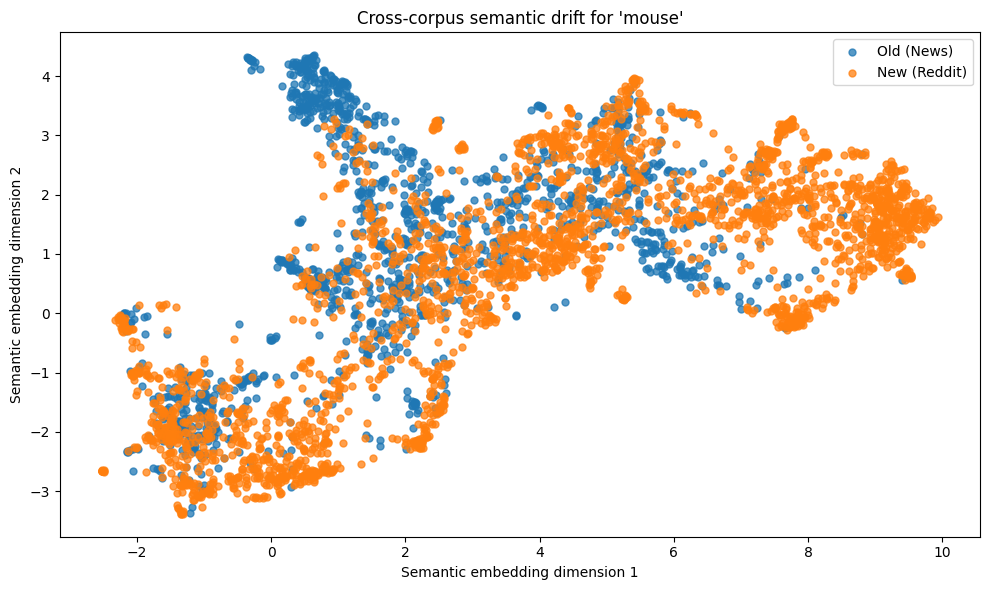

In [90]:
import umap.umap_ as umap
import matplotlib.pyplot as plt

all_emb = np.vstack([old_emb, new_emb])
labels = np.array(["Old (News)"] * len(old_emb) + ["New (Reddit)"] * len(new_emb))

reducer = umap.UMAP(n_components=2, random_state=42)
coords = reducer.fit_transform(all_emb)

old_mask = labels == "Old (News)"
new_mask = labels == "New (Reddit)"

plt.figure(figsize=(10, 6))
plt.scatter(coords[old_mask, 0], coords[old_mask, 1], s=25, alpha=0.75, label="Old (News)")
plt.scatter(coords[new_mask, 0], coords[new_mask, 1], s=25, alpha=0.75, label="New (Reddit)")
plt.title(f"Cross-corpus semantic drift for '{word}'")
plt.xlabel("Semantic embedding dimension 1")
plt.ylabel("Semantic embedding dimension 2")
plt.legend()
plt.tight_layout()
plt.show()

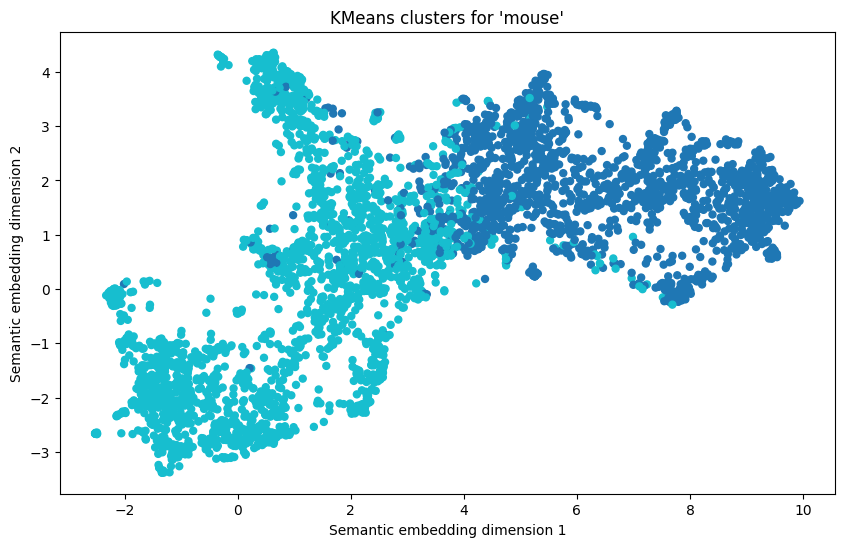

In [91]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(all_emb)

plt.figure(figsize=(10, 6))
plt.scatter(coords[:, 0], coords[:, 1], c=cluster_labels, cmap="tab10", s=25)
plt.title(f"KMeans clusters for '{word}'")
plt.xlabel("Semantic embedding dimension 1")
plt.ylabel("Semantic embedding dimension 2")
plt.show()

In [95]:
import pandas as pd

contexts = old_contexts + new_contexts

cluster_df = pd.DataFrame({
    "text": contexts,
    "cluster": cluster_labels
})

In [96]:
for c in sorted(cluster_df["cluster"].unique()):
    print("Cluster:", c)

    examples = cluster_df[cluster_df["cluster"] == c]["text"].head(10)

    for e in examples:
        print("-", e)

Cluster: 0
- At the end of his speech, Ban put his hand on the mouse of a laptop computer together with Jones, of Google; Carlos Dominguez, a Cisco Senior Vice President; and Kemal Dervis, U.N. Development Program Administrator.
- But end-users have traditionally downloaded megabytes of information from the web, while uploading only kilobytes of key strokes and mouse clicks.
- Finally, when Google shows you its suggested driving route on the map, you can drag that line onto another road with your mouse.
- We then watch a video of a driver's-eye view of a road (somewhere in Reading, according to the signposts) and click our mouse when we see a hazard.
- Internet Explorer rather redundantly displays the "alt" tag when the mouse is hovered over the image; Firefox doesn't bother because no alternative is needed and there is a `title' tag for captions.
- Now businesses are increasingly using networking tools such as LinkedIn and Facebook to identify those people with the click of a mouse.
-

In [97]:
corpus_labels = ["news"] * len(old_contexts) + ["reddit"] * len(new_contexts)

cluster_df = pd.DataFrame({
    "text": contexts,
    "cluster": cluster_labels,
    "source": corpus_labels
})

In [98]:
cluster_df.groupby(["cluster","source"]).size()

cluster  source
0        news       414
         reddit    1374
1        news      1086
         reddit    1289
dtype: int64

In [99]:
word = input("Enter a word: ").lower().strip()

news_contexts, reddit_contexts = prepare_contexts_for_word(word)


Enter a word: tablet
Generating news contexts for 'tablet'...
Processing: /content/drive/MyDrive/semantic-drift/news_crawl/news.2007.en.shuffled.deduped.gz
Processing: /content/drive/MyDrive/semantic-drift/news_crawl/news.2008.en.shuffled.deduped.gz
Processing: /content/drive/MyDrive/semantic-drift/news_crawl/news.2009.en.shuffled.deduped.gz
Saved: /content/drive/MyDrive/semantic-drift/news_dataset/tablet_news_contexts_clean.csv
Generating reddit contexts for 'tablet'...
Saved: /content/drive/MyDrive/semantic-drift/reddit_data/processed/monthly/tablet_reddit_contexts_clean.csv

Prepared contexts for 'tablet':
News contexts: 1477
Reddit contexts: 2706


In [111]:
test_words = [
    "stream",
]

In [119]:
for word in test_words:
    print("Analyzing:", word)

    news_contexts_for_current_word, reddit_contexts_for_current_word = prepare_contexts_for_word(word)

    old_emb = embed_model.encode(news_contexts_for_current_word, batch_size=64)
    new_emb = embed_model.encode(reddit_contexts_for_current_word, batch_size=64)

    old_mean = np.mean(old_emb, axis=0)
    new_mean = np.mean(new_emb, axis=0)

    drift_score = 1 - cosine_similarity(
        old_mean.reshape(1,-1),
        new_mean.reshape(1,-1)
    )[0][0]

    print("Drift score:", drift_score)

# After the loop, explicitly assign the contexts of the last processed word to global variables
# so subsequent cells use the correct data.
old_contexts = news_contexts_for_current_word
new_contexts = reddit_contexts_for_current_word

Analyzing: stream
Loading existing news contexts for 'stream'...
Loading existing reddit contexts for 'stream'...

Prepared contexts for 'stream':
News contexts: 1500
Reddit contexts: 2576
Drift score: 0.28321475


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


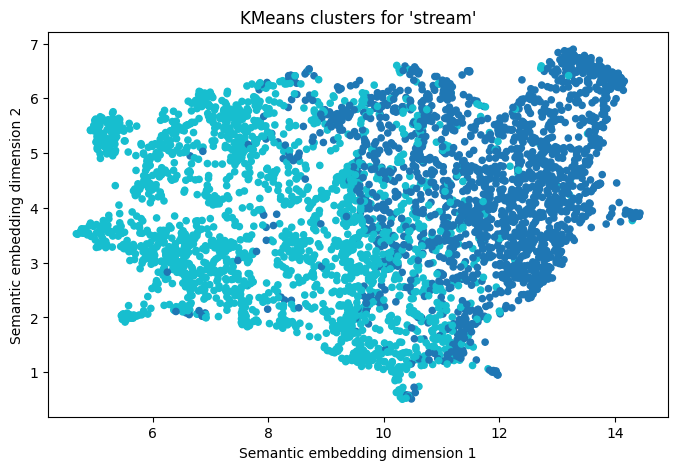

In [113]:
all_emb = np.vstack([old_emb, new_emb])

kmeans = KMeans(n_clusters=2, random_state=42)
cluster_labels = kmeans.fit_predict(all_emb)

reducer = umap.UMAP(random_state=42)
coords = reducer.fit_transform(all_emb)

plt.figure(figsize=(8,5))
plt.scatter(coords[:,0], coords[:,1], c=cluster_labels, cmap="tab10", s=20)

plt.title(f"KMeans clusters for '{word}'")
plt.xlabel("Semantic embedding dimension 1")
plt.ylabel("Semantic embedding dimension 2")

plt.show()

In [121]:
import pandas as pd

contexts = old_contexts + new_contexts

cluster_df = pd.DataFrame({
    "text": contexts,
    "cluster": cluster_labels
})

In [122]:
for c in sorted(cluster_df["cluster"].unique()):
    print("Cluster:", c)

    examples = cluster_df[cluster_df["cluster"] == c]["text"].head(15)

    for e in examples:
        print("-", e)

Cluster: 0
- Two Digital Stream converter models, the DigitalSTREAM D2A1D10 and DigitalSTREAM D2A1D20, have been approved by the NTIA.
- ATI announced the first Stream product last year, but AMD didn't work hard to promote it.
- Web stream
- At the end of September approximately 48% of Stream's networks have been modernized to be bidirectional.
- Together, the surveillance systems let FBI agents play back recordings even as they are being captured (like TiVo), create master wiretap files, send digital recordings to translators, track the rough location of targets in real time using cell-tower information, and even stream intercepts outward to mobile surveillance vans.
- The only encoder to support AVC, VC-1, and MPEG-2 stream creation in one system, CineVision Version 2.5 was developed based on direct feedback from leading Hollywood image-quality experts.
- About Stream Communications
- In order to simplify Stream Poland's corporate structure while reducing management overhead and unne

In [123]:
test_words = [
    "viral",
]

In [124]:
for word in test_words:
    print("Analyzing:", word)

    news_contexts_for_current_word, reddit_contexts_for_current_word = prepare_contexts_for_word(word)

    old_emb = embed_model.encode(news_contexts_for_current_word, batch_size=64)
    new_emb = embed_model.encode(reddit_contexts_for_current_word, batch_size=64)

    old_mean = np.mean(old_emb, axis=0)
    new_mean = np.mean(new_emb, axis=0)

    drift_score = 1 - cosine_similarity(
        old_mean.reshape(1,-1),
        new_mean.reshape(1,-1)
    )[0][0]

    print("Drift score:", drift_score)

# After the loop, explicitly assign the contexts of the last processed word to global variables
# so subsequent cells use the correct data.
old_contexts = news_contexts_for_current_word
new_contexts = reddit_contexts_for_current_word

Analyzing: viral
Loading existing news contexts for 'viral'...
Loading existing reddit contexts for 'viral'...

Prepared contexts for 'viral':
News contexts: 1500
Reddit contexts: 2787
Drift score: 0.28926712


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


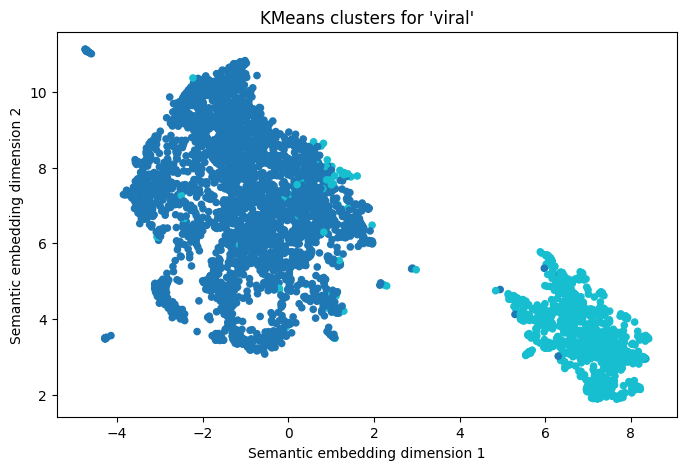

In [125]:
all_emb = np.vstack([old_emb, new_emb])

kmeans = KMeans(n_clusters=2, random_state=42)
cluster_labels = kmeans.fit_predict(all_emb)

reducer = umap.UMAP(random_state=42)
coords = reducer.fit_transform(all_emb)

plt.figure(figsize=(8,5))
plt.scatter(coords[:,0], coords[:,1], c=cluster_labels, cmap="tab10", s=20)

plt.title(f"KMeans clusters for '{word}'")
plt.xlabel("Semantic embedding dimension 1")
plt.ylabel("Semantic embedding dimension 2")

plt.show()

In [126]:
import pandas as pd

contexts = old_contexts + new_contexts

cluster_df = pd.DataFrame({
    "text": contexts,
    "cluster": cluster_labels
})

In [127]:
for c in sorted(cluster_df["cluster"].unique()):
    print("Cluster:", c)

    examples = cluster_df[cluster_df["cluster"] == c]["text"].head(15)

    for e in examples:
        print("-", e)

Cluster: 0
- Doing the 'Aunt Jackie': A Harlem-filmed rap video goes viral on MySpace.
- Embarrassing moments go viral too, as when Miss South Carolina Teen USA Lauren Caitlin Upton was asked during the televised pageant to answer the question "Recent polls have shown a fifth of Americans can't locate the U.S. on a world map.
- Our launch program is built on a Viral Marketing and college grassroots strategy to capitalize on the inherent appeal that we believe ThePeeq.com will have with their audience.
- Viral events are unpredictable.
- By some estimates, the Star Wars kid is the most popular viral video ever, and viewed over one billion times.
- A writer pays for breaking the strike in this "viral" video "Viral" video
- Hupo.TV, recognized recently by PC World China as one of the top 10 video sites in China, is known for its original and contagious/viral content that keeps the consumers coming back for more.
- There's no evidence that Adblock Plus or similar products are about to go v

In [128]:
test_words = [
    "tablet",
]

In [129]:
for word in test_words:
    print("Analyzing:", word)

    news_contexts_for_current_word, reddit_contexts_for_current_word = prepare_contexts_for_word(word)

    old_emb = embed_model.encode(news_contexts_for_current_word, batch_size=64)
    new_emb = embed_model.encode(reddit_contexts_for_current_word, batch_size=64)

    old_mean = np.mean(old_emb, axis=0)
    new_mean = np.mean(new_emb, axis=0)

    drift_score = 1 - cosine_similarity(
        old_mean.reshape(1,-1),
        new_mean.reshape(1,-1)
    )[0][0]

    print("Drift score:", drift_score)

# After the loop, explicitly assign the contexts of the last processed word to global variables
# so subsequent cells use the correct data.
old_contexts = news_contexts_for_current_word
new_contexts = reddit_contexts_for_current_word

Analyzing: tablet
Loading existing news contexts for 'tablet'...
Loading existing reddit contexts for 'tablet'...

Prepared contexts for 'tablet':
News contexts: 1477
Reddit contexts: 2706
Drift score: 0.23101544


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


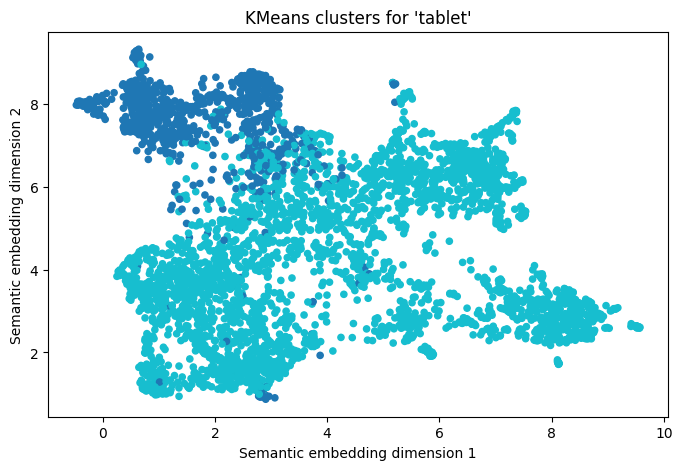

In [130]:
all_emb = np.vstack([old_emb, new_emb])

kmeans = KMeans(n_clusters=2, random_state=42)
cluster_labels = kmeans.fit_predict(all_emb)

reducer = umap.UMAP(random_state=42)
coords = reducer.fit_transform(all_emb)

plt.figure(figsize=(8,5))
plt.scatter(coords[:,0], coords[:,1], c=cluster_labels, cmap="tab10", s=20)

plt.title(f"KMeans clusters for '{word}'")
plt.xlabel("Semantic embedding dimension 1")
plt.ylabel("Semantic embedding dimension 2")

plt.show()

In [131]:
import pandas as pd

contexts = old_contexts + new_contexts

cluster_df = pd.DataFrame({
    "text": contexts,
    "cluster": cluster_labels
})

In [132]:
for c in sorted(cluster_df["cluster"].unique()):
    print("Cluster:", c)

    examples = cluster_df[cluster_df["cluster"] == c]["text"].head(15)

    for e in examples:
        print("-", e)

Cluster: 0
- The HAVA Mobile Player for Nokia Internet Tablets was designed for seamless integration with Nokia's unique multimedia device allowing viewers to control the television (whether cable or satellite, receiver or DVR, standard or high definition) via the Internet Tablet's physical keys or stylus in real time over a WiFi or WiMAX connection.
- I generally had to leave the Tablet Properties dialog open on the other display for "quick" reference.
- Monsoon Multimedia Announces Availability of HAVA Mobile Player for Nokia Internet Tablet
- Available from Monsoon as a free download, the HAVA Mobile Player allows HAVA customers to view and control their home television and services, including satellite and TiVo, from anywhere in the world on a Nokia Internet Tablet.
- Monsoon's HAVA features unique video multicasting capabilities which allow users to broadcast their home television to multiple devices within their home network while simultaneously place- shifting video to a connect

In [133]:
test_words = [
    "thread",
]

In [134]:
for word in test_words:
    print("Analyzing:", word)

    news_contexts_for_current_word, reddit_contexts_for_current_word = prepare_contexts_for_word(word)

    old_emb = embed_model.encode(news_contexts_for_current_word, batch_size=64)
    new_emb = embed_model.encode(reddit_contexts_for_current_word, batch_size=64)

    old_mean = np.mean(old_emb, axis=0)
    new_mean = np.mean(new_emb, axis=0)

    drift_score = 1 - cosine_similarity(
        old_mean.reshape(1,-1),
        new_mean.reshape(1,-1)
    )[0][0]

    print("Drift score:", drift_score)

# After the loop, explicitly assign the contexts of the last processed word to global variables
# so subsequent cells use the correct data.
old_contexts = news_contexts_for_current_word
new_contexts = reddit_contexts_for_current_word

Analyzing: thread
Generating news contexts for 'thread'...
Processing: /content/drive/MyDrive/semantic-drift/news_crawl/news.2007.en.shuffled.deduped.gz
Processing: /content/drive/MyDrive/semantic-drift/news_crawl/news.2008.en.shuffled.deduped.gz
Processing: /content/drive/MyDrive/semantic-drift/news_crawl/news.2009.en.shuffled.deduped.gz
Saved: /content/drive/MyDrive/semantic-drift/news_dataset/thread_news_contexts_clean.csv
Generating reddit contexts for 'thread'...
Saved: /content/drive/MyDrive/semantic-drift/reddit_data/processed/monthly/thread_reddit_contexts_clean.csv

Prepared contexts for 'thread':
News contexts: 1500
Reddit contexts: 3406
Drift score: 0.33685148


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


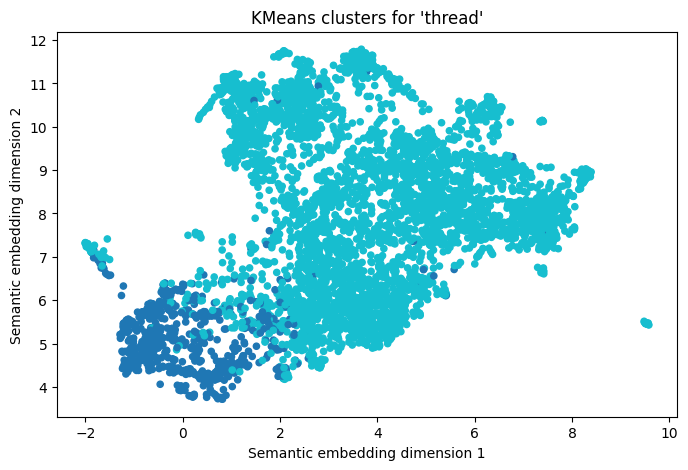

In [136]:
all_emb = np.vstack([old_emb, new_emb])

kmeans = KMeans(n_clusters=2, random_state=42)
cluster_labels = kmeans.fit_predict(all_emb)

reducer = umap.UMAP(random_state=42)
coords = reducer.fit_transform(all_emb)

plt.figure(figsize=(8,5))
plt.scatter(coords[:,0], coords[:,1], c=cluster_labels, cmap="tab10", s=20)

plt.title(f"KMeans clusters for '{word}'")
plt.xlabel("Semantic embedding dimension 1")
plt.ylabel("Semantic embedding dimension 2")

plt.show()

In [137]:
import pandas as pd

contexts = old_contexts + new_contexts

cluster_df = pd.DataFrame({
    "text": contexts,
    "cluster": cluster_labels
})

In [138]:
for c in sorted(cluster_df["cluster"].unique()):
    print("Cluster:", c)

    examples = cluster_df[cluster_df["cluster"] == c]["text"].head(15)

    for e in examples:
        print("-", e)

Cluster: 0
- The Mixx private beta will undergo a rapid transformation as the program progresses with incorporation of beta user feedback, addition of video thumbnails and embeds, and improvements in site performance as navigation tags and group metaphors begin to thread throughout the system.
- It also has an embedded security thread.
- Some report resorting to re-booting their machine to free themselves of it but others stopped it by killing the Firefox process thread.
- Nick.com will also feature a custom video player, links to additional SpongeBob SquarePants games, a special message board thread and a page of downloadable wallpapers, screensaver, printables and buddy icons.
- We're here to bring you commentary not on the game itself - for that, go over to John Woods's live game thread on this blog - but rather on the telecast itself.
- Tomorrow, on April 25th at Noon ET, I will be available here on this Newsvine thread to answer your questions about the procedure.
- And certainly 